In [1]:
import numpy as np  
import matplotlib.pyplot as plt  
import sklearn  
import sklearn.datasets  
import sklearn.linear_model

Generate and visualize data examples. Please note that the shape of X is (2,m) and the shape of Y is (1,m). Thus, the dataset has m examples, and each example has two input features and one label (0 or 1).

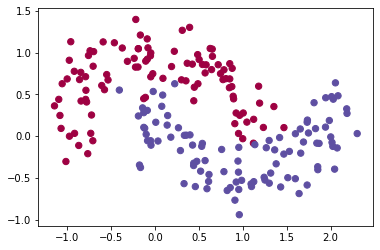

In [2]:
np.random.seed(1) 

m=200 # the number of samples
X, Y = sklearn.datasets.make_moons(n_samples=m, noise=.2)  
X, Y = X.T, Y.reshape(1, Y.shape[0])  

# X: X(2,m), Y: Y(1,m)

# Visualize the data   
plt.scatter(X[0, :], X[1, :], c=Y[0,:], s=40, cmap=plt.cm.Spectral);  
  
plt.show()  

In [3]:
# this function plots the predictions for all points.

def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the function value for the whole grid
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[0, :], X[1, :], c=y[0,:], cmap=plt.cm.Spectral)

In [4]:
# sigmoid function
def sigmoid(x):
    s = 1/(1+np.exp(-x))
    return s

In [5]:
def layer_sizes(X, Y):  
    """  
    Argument:  
    X -- input dataset of shape (input size, number of examples)  
    Y -- labels of shape (output size, number of examples)  
    Return:  
    n_x -- the number of nodes in the input layer  
    n_y -- the number of nodes in the output layer  
    """  
    ### extract the layer sizes from input and output shapes ### 
    n_x = X.shape[0] # size of input layer  
    n_y = Y.shape[0] # size of output layer  
    ######  
    return (n_x, n_y)  


In [6]:
# FUNCTION: initialize_parameters  
  
def initialize_parameters(n_x, n_h, n_y):  
    """  
    Argument:  
    n_x -- size of the input layer  
    n_h -- size of the hidden layer  
    n_y -- size of the output layer  
    Returns:  
    params -- python dictionary containing parameters:  
                    W1 -- weight matrix of shape (n_h, n_x)  
                    b1 -- bias vector of shape (n_h, 1)  
                    W2 -- weight matrix of shape (n_y, n_h)  
                    b2 -- bias vector of shape (n_y, 1)  
    """  
    np.random.seed(2) # set up a seed for reproductivity.  
        
    W1 = np.random.randn(n_h, n_x) * 0.01  # random numbers for weights
    b1 = np.zeros((n_h, 1))                # zeros for bias
    W2 = np.random.randn(n_y, n_h) * 0.01  
    b2 = np.zeros((n_y,1))  

    assert (W1.shape == (n_h, n_x))  
    assert (b1.shape == (n_h, 1))  
    assert (W2.shape == (n_y, n_h))  
    assert (b2.shape == (n_y, 1))  
      
    parameters = {"W1": W1,  
                  "b1": b1,  
                  "W2": W2,  
                  "b2": b2}  
      
    return parameters  


In [7]:
# FUNCTION: forward_propagation  

def forward_propagation(X, parameters):  
    """  
    Argument:  
    X -- input data of size (n_x, m)  
    parameters -- python dictionary containing your parameters  
      
    Return:  
    A2 -- The sigmoid output of the second activation  
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2"  
    """  
    # Retrieve each parameter from the dictionary "parameters"  
    W1 = parameters["W1"]  
    b1 = parameters["b1"]  
    W2 = parameters["W2"]  
    b2 = parameters["b2"]  
      
    # Implement Forward Propagation to calculate A2 (probabilities)   
    Z1 = np.dot(W1, X) + b1  
    A1 =  np.tanh(Z1)  
    Z2 = np.dot(W2, A1) + b2  
    A2 = sigmoid(Z2)  
     
    assert(A2.shape == (1, X.shape[1]))  
      
    cache = {"Z1": Z1,  
             "A1": A1,  
             "Z2": Z2,  
             "A2": A2}  # Results at all layers
      
    return A2, cache  


In [8]:
# FUNCTION: compute_cost  

def compute_cost(A2, Y, parameters):  
    """  
    Computes the cross-entropy loss  
      
    Argument:  
    A2 -- The output of the seccond layer, of shape (1, number of examples)  
    Y -- "true" labels vector of shape (1, number of examples)  
    parameters -- python dictionary containing parameters W1, b1, W2 and b2  
      
    Return:  
    cost -- cross-entropy loss 
    """  
      
    m = Y.shape[1] # number of examples  
  
    # Compute the cross-entropy cost  
    logprobs = np.multiply(np.log(A2),Y) +  np.multiply(np.log(1-A2), (1-Y))  
    cost = -1/m*np.sum(logprobs)  
     
    cost = np.squeeze(cost)     # makes sure cost is the dimension we expect.   
                                # E.g., turns [[17]] into 17   
    assert(isinstance(cost, float))  
      
    return cost  


In [9]:
# FUNCTION: backward_propagation  
  
def backward_propagation(parameters, cache, X, Y):  
    """  
    Implement the backward propagation.  
      
    Argument:  
    parameters -- python dictionary containing parameters   
    cache -- a dictionary containing "Z1", "A1", "Z2" and "A2".  
    X -- input data of shape (n_x, number of examples)  
    Y -- "true" labels vector of shape (1, number of examples)  
      
    Return:  
    grads -- python dictionary containing gradients with respect to different parameters  
    """  
    m = X.shape[1]  # number of examples
      
    # First, retrieve W1 and W2 from the dictionary "parameters".   
    W1 = parameters["W1"]  
    W2 = parameters["W2"]  
      
    # Second, retrieve A1 and A2 from dictionary "cache".  
    A1 = cache["A1"]  
    A2 =  cache["A2"]  
     
    # Backward propagation: calculate dW1, db1, dW2, db2.   
    dZ2= A2-Y  
    dW2 = 1./m*np.dot(dZ2, A1.T)  
    db2 = 1./m*np.sum(dZ2, axis = 1, keepdims=True)  
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))  
    dW1 = 1./m* np.dot(dZ1, X.T)  
    db1 = 1./m*np.sum(dZ1, axis = 1, keepdims=True)  
      
    # Save the results
    grads = {"dW1": dW1,  
             "db1": db1,  
             "dW2": dW2,  
             "db2": db2}  
      
    return grads  


In [10]:
#  FUNCTION: update_parameters  
  
def update_parameters(parameters, grads, learning_rate = 1.2):  
    """  
    Update parameters using the gradient descent    
      
    Argument:  
    parameters -- python dictionary containing parameters   
    grads -- python dictionary containing gradients   
      
    Return:  
    parameters -- python dictionary containing updated parameters   
    """  
    # Retrieve each parameter from the dictionary "parameters"    
    W1 = parameters["W1"]  
    W2 = parameters["W2"]  
    b1 = parameters["b1"]  
    b2 = parameters["b2"]  
   
    # Retrieve each gradient from the dictionary "grads"   
    dW1 = grads["dW1"]  
    db1 = grads["db1"]  
    dW2 = grads["dW2"]  
    db2 = grads["db2"]  
    
    # Update for each parameter    
    W1 = W1 - dW1 * learning_rate  
    b1 = b1 - db1 * learning_rate  
    W2 = W2 - dW2 * learning_rate  
    b2 = b2 - db2 * learning_rate   
    
    # Save updated parameter results
    parameters = {"W1": W1,  
                  "b1": b1,  
                  "W2": W2,  
                  "b2": b2}  
      
    return parameters  


In [11]:
# FUNCTION: nn_model  
  
def nn_model(X, Y, n_h, num_iterations = 10000, print_cost=False):  
    """  
    define a model: input, output, hidden layer size, iteration numbers, print_cost or not.
    Argument:  
    X -- input shape (2, number of examples)  
    Y -- label shape (1, number of examples)  
    n_h -- size of the hidden layer  
    num_iterations -- number of iterations in update loop  
    print_cost -- if True, print the cost every 1000 iterations  
      
    Return:  
    parameters -- learned parameters.    
    """  
      
    np.random.seed(3)  
    n_x = layer_sizes(X, Y)[0]  
    n_y = layer_sizes(X, Y)[1]  
      
    # Initialize parameters, then retrieve W1, b1, W2, b2. 
    # Inputs: "n_x, n_h, n_y". 
    # Outputs: "parameters".  
    parameters = initialize_parameters(n_x, n_h, n_y)  
    W1 = parameters["W1"]  
    W2 = parameters["W2"]  
    b1 = parameters["b1"]  
    b2 = parameters["b2"]  
    
    # Loop (gradient descent)  
  
    for i in range(0, num_iterations):  
           
        # Forward propagation. Inputs: "X, parameters". Outputs: "A2, cache".  
        A2, cache = forward_propagation(X, parameters)  
          
        # Cost function. Inputs: "A2, Y, parameters". Outputs: "cost".  
        cost = compute_cost(A2, Y, parameters)  
   
        # Backpropagation. Inputs: "parameters, cache, X, Y". Outputs: "grads".  
        grads = backward_propagation(parameters, cache, X, Y)  
   
        # Gradient descent parameter update. Inputs: "parameters, grads". Outputs: "parameters".  
        parameters = update_parameters(parameters, grads)  
          
        # Print the cost every 1000 iterations  
        if print_cost and i % 1000 == 0:  
            print ("Cost after iteration %i: %f" %(i, cost))  
  
    return parameters  


In [12]:
# FUNCTION: predict  
  
def predict(parameters, X):  
    """  
    predicts a class for each example in X  
      
    Arguments:  
    parameters -- python dictionary containing your parameters   
    X -- input data of size (n_x, m)  
    Returns  
    predictions -- vector of predictions of our model (red: 0 / blue: 1)  
    """  
    # Computes probabilities using forward propagation, and classifies to 0/1 using 0.5 as the threshold.  
    
    A2, cache = forward_propagation(X, parameters)  
    predictions = A2 > 0.5  
    
    return predictions  


Cost after iteration 0: 0.692995
Cost after iteration 1000: 0.090063
Cost after iteration 2000: 0.064688
Cost after iteration 3000: 0.056812
Cost after iteration 4000: 0.050300
Cost after iteration 5000: 0.044030
Cost after iteration 6000: 0.043814
Cost after iteration 7000: 0.042719
Cost after iteration 8000: 0.041756
Cost after iteration 9000: 0.040949
Accuracy of nn:  0.985
parameters are  {'W1': array([[-4.60909564,  4.50592485],
       [ 2.77721501,  2.62387821],
       [-6.12507597,  0.32178735],
       [12.79405415, -6.32560328]]), 'b1': array([[ 6.12498998],
       [-2.22646889],
       [-4.01149508],
       [ 3.28497244]]), 'W2': array([[-10.37014269, -13.33751484,  -4.32423522,   6.68597777]]), 'b2': array([[-0.48635814]])}


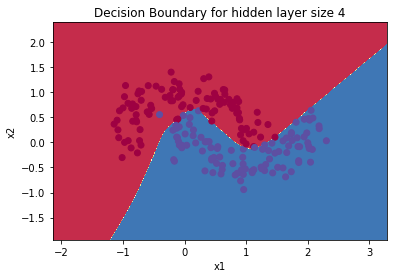

In [13]:
from sklearn.metrics import accuracy_score 
# Build a model with a n_h-dimensional hidden layer  
n_h=4
parameters = nn_model(X, Y, n_h, num_iterations = 10000, print_cost=True)  
  
# Plot the decision boundary  
plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)  
plt.title("Decision Boundary for hidden layer size " + str(n_h))  
  
predictions = predict(parameters, X)  
accuracy_nn = accuracy_score((Y.T).flatten(),predictions.T)  
print('Accuracy of nn: ', accuracy_nn)  
  
print('parameters are ', parameters)  


Cost after iteration 0: 0.693127
Cost after iteration 1000: 0.285920
Cost after iteration 2000: 0.229398
Cost after iteration 3000: 0.061624
Cost after iteration 4000: 0.050656
Cost after iteration 5000: 0.046280
Cost after iteration 6000: 0.043562
Cost after iteration 7000: 0.041473
Cost after iteration 8000: 0.039757
Cost after iteration 9000: 0.038316
Accuracy of nn:  0.98


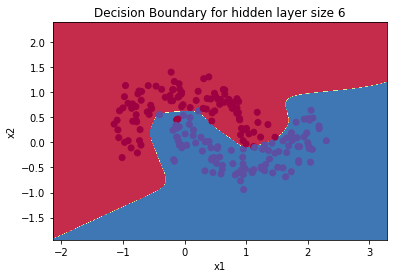

In [16]:

n_h = 6
parameters = nn_model(X, Y, n_h, num_iterations = 10000, print_cost=True)  
  
# Plot the decision boundary  
plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)  
plt.title("Decision Boundary for hidden layer size " + str(n_h))  
  
predictions = predict(parameters, X)  
accuracy_nn = accuracy_score((Y.T).flatten(),predictions.T)  
print('Accuracy of nn: ', accuracy_nn)  
